In [12]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [13]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [14]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
categorical_features = ["Month", "VisitorType", "Weekend"]
cat_indices = [X_train.columns.get_loc(col) for col in categorical_features]

print("SMOTE 之前的类别分布：\n", y_train.value_counts())


SMOTE 之前的类别分布：
 Revenue
False    8338
True     1526
Name: count, dtype: int64


In [16]:
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

print("\nSMOTE 之后的类别分布：\n", y_train_resampled.value_counts())


SMOTE 之后的类别分布：
 Revenue
False    8338
True     8338
Name: count, dtype: int64


In [17]:
preprocessor = ColumnTransformer(
	transformers=[
		(
			"cat",
			OneHotEncoder(handle_unknown="ignore"),
			categorical_features
		)
	],
	remainder="passthrough"
)

In [18]:
X_train_processed = preprocessor.fit_transform(X_train_resampled)
X_test_processed = preprocessor.transform(X_test)

In [23]:
# 5. XGBoost 训练
xgb = XGBClassifier(
	objective="binary:logistic",
	eval_metric="logloss",
	random_state=42,
	scale_pos_weight=5.46
)


In [24]:
param_dist = {
	"n_estimators": [100, 200, 300],
	"max_depth": [3, 5, 7],
	"learning_rate": [0.01, 0.05, 0.1],
	"subsample": [0.8, 1.0],
	"colsample_bytree": [0.8, 1.0],
	"min_child_weight": [1, 3, 5],
	"gamma": [0, 0.1, 0.3]
}


In [25]:
random_search = RandomizedSearchCV(
	estimator=xgb,
	param_distributions=param_dist,
	n_iter=30,
	scoring="f1",  # 或者用 "roc_auc"
	cv=5,
	verbose=2,
	random_state=42,
	n_jobs=-1
)

# 注意：传入的是 resampled 之后的 y_train_resampled
random_search.fit(X_train_processed, y_train_resampled)

# 打印最佳参数
print("\nBest Parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}


Model Evaluation Metrics (SMOTENC + XGBoost)
Accuracy  : 0.8698
Precision : 0.5588
Recall    : 0.7592
F1 Score  : 0.6437

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2084
        True       0.56      0.76      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.82      0.78      2466
weighted avg       0.89      0.87      0.88      2466



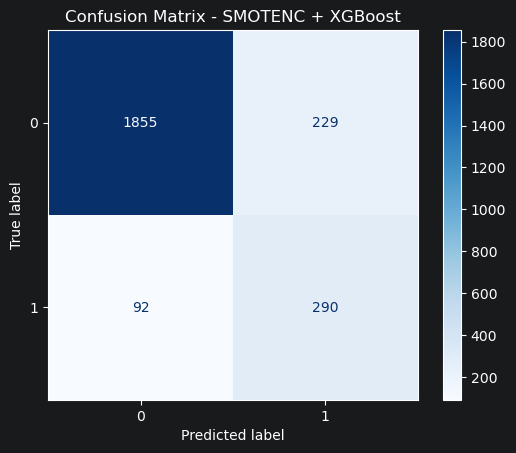

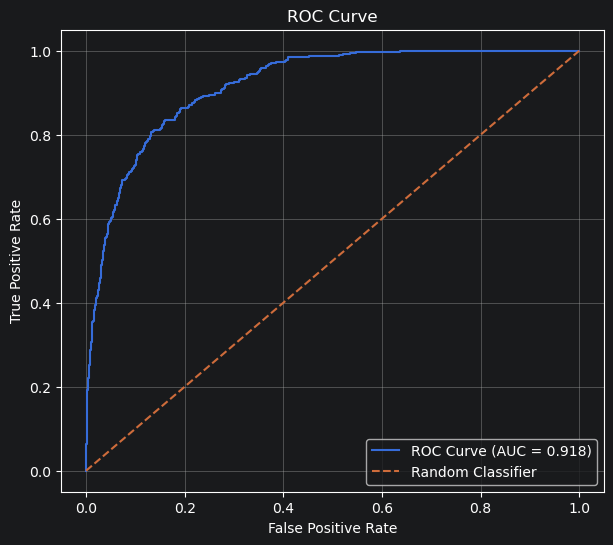

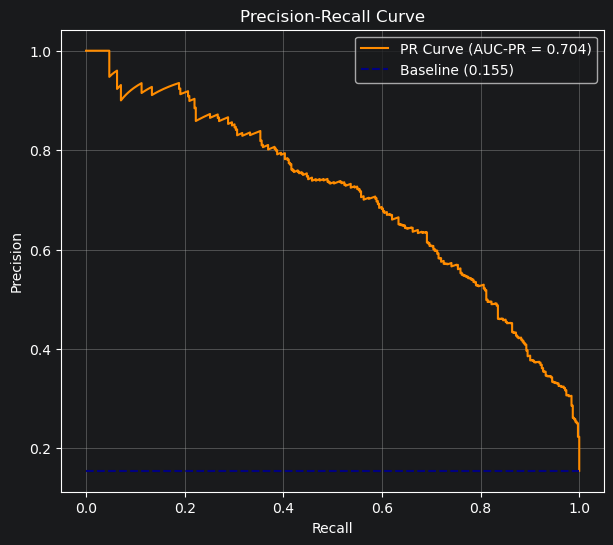

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
	accuracy_score, precision_score, recall_score, f1_score,
	confusion_matrix, classification_report, roc_curve, auc,
	precision_recall_curve, ConfusionMatrixDisplay
)

# 1. 提取随机搜索找到的最优模型
best_model = random_search.best_estimator_
# 2. 在测试集上进行预测（获取类别预测和概率预测）
y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:, 1]
# 3. 打印基础分类指标 (参照 02_Preprocessing.ipynb 的风格)
print("=" * 50)
print("Model Evaluation Metrics (SMOTENC + XGBoost)")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# 4. 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix - SMOTENC + XGBoost")
plt.show()
# 5. 绘制 ROC 曲线并计算 AUC-ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
# 6. 绘制 AUC-PR (Precision-Recall) 曲线并计算 PR-AUC (新增)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
plt.figure(figsize=(7, 6))
# 绘制 PR 曲线
plt.plot(recall, precision, color='darkorange', label=f"PR Curve (AUC-PR = {pr_auc:.3f})")
# 绘制 Baseline (对于 PR 曲线，随机猜测的水平线等于测试集中正样本的比例)
baseline = sum(y_test) / len(y_test)
plt.plot([0, 1], [baseline, baseline], linestyle="--", color='navy', label=f"Baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline  # 注意:用 imblearn 的 Pipeline,不是 sklearn 的
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
	accuracy_score, precision_score, recall_score, f1_score
)

df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

X = df.drop("Revenue", axis=1)
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = ["Month", "VisitorType", "Weekend"]
cat_indices = [X_train.columns.get_loc(col) for col in categorical_features]

print("原始训练集类别分布：\n", y_train.value_counts())

# --- 关键改动1: SMOTENC 放在 pipeline 里，不再提前手动 resample ---
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

# --- OneHotEncoder 放在 SMOTE 之后（pipeline 里顺序执行）---
preprocessor = ColumnTransformer(
	transformers=[
		("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
	],
	remainder="passthrough"
)

# --- 关键改动2: 去掉 scale_pos_weight，避免和 SMOTE 重复纠偏 ---
xgb = XGBClassifier(
	objective="binary:logistic",
	eval_metric="logloss",
	random_state=42
	# scale_pos_weight=5.46  # 不再需要，SMOTE 已经在做平衡
)

# --- 用 imblearn Pipeline 串联：SMOTE -> 编码 -> 模型 ---
pipeline = Pipeline(steps=[
	("smote", smote_nc),
	("preprocessor", preprocessor),
	("xgb", xgb)
])

param_dist = {
	"xgb__n_estimators": [100, 200, 300],
	"xgb__max_depth": [3, 5, 7],
	"xgb__learning_rate": [0.01, 0.05, 0.1],
	"xgb__subsample": [0.8, 1.0],
	"xgb__colsample_bytree": [0.8, 1.0],
	"xgb__min_child_weight": [1, 3, 5],
	"xgb__gamma": [0, 0.1, 0.3]
}

random_search = RandomizedSearchCV(
	estimator=pipeline,
	param_distributions=param_dist,
	n_iter=30,
	scoring="f1",  # 或者 "roc_auc"，不平衡数据建议两个都看
	cv=5,
	verbose=2,
	random_state=42,
	n_jobs=-1
)

# --- 关键改动3: 直接传入原始 X_train, y_train，SMOTE 在每折内部自动执行 ---
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)

# --- 用最佳模型在真正的 test set（没有 SMOTE，没有泄漏）上评估 ---
best_model = random_search.best_estimator_
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

原始训练集类别分布：
 Revenue
False    8338
True     1526
Name: count, dtype: int64
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'xgb__subsample': 0.8, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 1, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.8}
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2084
        True       0.59      0.75      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.79      2466
weighted avg       0.90      0.88      0.89      2466

ROC-AUC: 0.9248562972937665
Accuracy  : 0.8804
Precision : 0.5901
Recall    : 0.7461
F1 Score  : 0.6590
